In [17]:
import pandas as pd
import numpy as np
import altair as alt
import matplotlib.pyplot as plt

In [49]:
owid = pd.read_csv("../data/owid-covid-data.csv")
owid["date"] = pd.to_datetime(owid["date"])

In [3]:
selected_countries = [
    "United States", "China", "New Zealand", "Sweden", "Brazil", "Germany",
    "United Kingdom", "France", "Italy", "Spain",
    "Canada", "Australia", "Japan", "South Korea", "Singapore",
    "Netherlands", "Belgium", "Denmark", "Norway"
]
owid_filter = owid[owid['location'].isin(selected_countries)].copy()

owid_filter = owid_filter[~owid_filter['iso_code'].str.startswith('OWID')]

owid_filter["week"] = owid_filter["date"].dt.to_period("W").dt.start_time
owid_filter = owid_filter.sort_values(["location", "date"])


## average variables:
avg_vars = [
    "new_cases_smoothed_per_million",
    "new_deaths_smoothed_per_million",
    "reproduction_rate",
    "positive_rate",
    "stringency_index",
    "icu_patients_per_million",
    "hosp_patients_per_million",
    "weekly_icu_admissions_per_million"
]

## last value variables
last_vars = [
    "people_vaccinated_per_hundred",
    "people_fully_vaccinated_per_hundred",
    "total_boosters_per_hundred",
    "total_vaccinations_per_hundred"
]

## static:
static_vars = [
    "population_density",
    "median_age",
    "aged_65_older",
    "aged_70_older",
    "gdp_per_capita",
    "extreme_poverty",
    "cardiovasc_death_rate",
    "diabetes_prevalence",
    "female_smokers",
    "male_smokers",
    "handwashing_facilities",
    "hospital_beds_per_thousand",
    "life_expectancy",
    "human_development_index"
]

agg_dict = {}

# Average
for col in avg_vars:
    agg_dict[col] = "mean"

# Last value
for col in last_vars:
    agg_dict[col] = "last"

# Static (just take first value per country)
for col in static_vars:
    agg_dict[col] = "first"

weeklyowid_df = (
    owid_filter
    .groupby(["location", "week"])
    .agg(agg_dict)
    .reset_index()
)

weeklyowid_df = weeklyowid_df.rename(columns={"location": "country"})

In [4]:
weeklyowid_df = weeklyowid_df.sort_values(["country", "week"])
weeklyowid_df[avg_vars + last_vars] = (
    weeklyowid_df.groupby("country")[avg_vars + last_vars].ffill()
)

In [5]:
weeklyowid_df = weeklyowid_df.dropna(subset=["new_deaths_smoothed_per_million"])
weeklyowid_df["stringency_lag_2"] = weeklyowid_df.groupby("country")["stringency_index"].shift(2)
weeklyowid_df["stringency_lag_3"] = weeklyowid_df.groupby("country")["stringency_index"].shift(3)
weeklyowid_df["stringency_lag_4"] = weeklyowid_df.groupby("country")["stringency_index"].shift(4)

In [6]:
weeklyowid_df.columns
(weeklyowid_df.isna().mean() * 100).round(2)

country                                  0.00
week                                     0.00
new_cases_smoothed_per_million           0.00
new_deaths_smoothed_per_million          0.00
reproduction_rate                        3.21
positive_rate                           17.06
stringency_index                         0.00
icu_patients_per_million                31.26
hosp_patients_per_million               33.48
weekly_icu_admissions_per_million       68.57
people_vaccinated_per_hundred           22.25
people_fully_vaccinated_per_hundred     23.09
total_boosters_per_hundred              33.39
total_vaccinations_per_hundred          21.70
population_density                       0.00
median_age                               0.00
aged_65_older                            0.00
aged_70_older                            0.00
gdp_per_capita                           0.00
extreme_poverty                         31.59
cardiovasc_death_rate                    0.00
diabetes_prevalence               

In [7]:
# Make a copy
model_df = weeklyowid_df.copy()

# Sort first
model_df = model_df.sort_values(["country", "week"])

# 1. Drop variables with too much missingness / weaker value
drop_cols = [
    "handwashing_facilities",
    "icu_patients_per_million",
    "hosp_patients_per_million",
    "extreme_poverty"
]

model_df = model_df.drop(columns=drop_cols, errors="ignore")

# 2. Forward fill important time-series variables within each country
fill_cols = [
    "reproduction_rate",
    "positive_rate",
    "people_vaccinated_per_hundred",
    "people_fully_vaccinated_per_hundred",
    "total_vaccinations_per_hundred",
    "total_boosters_per_hundred",
    "stringency_index"
]

fill_cols = [col for col in fill_cols if col in model_df.columns]

model_df[fill_cols] = (
    model_df.groupby("country")[fill_cols].ffill()
)

# 3. Recreate lag variables after sorting/filling
model_df["stringency_lag_2"] = model_df.groupby("country")["stringency_index"].shift(2)
model_df["stringency_lag_3"] = model_df.groupby("country")["stringency_index"].shift(3)
model_df["stringency_lag_4"] = model_df.groupby("country")["stringency_index"].shift(4)

# 4. Drop rows missing target
model_df = model_df.dropna(subset=["new_deaths_smoothed_per_million"])

# 5. Optional: keep only columns you want for modeling
model_vars = [
    "country",
    "week",
    "new_deaths_smoothed_per_million",
    "new_cases_smoothed_per_million",
    "reproduction_rate",
    "positive_rate",
    "stringency_index",
    "stringency_lag_2",
    "stringency_lag_3",
    "stringency_lag_4",
    "people_vaccinated_per_hundred",
    "people_fully_vaccinated_per_hundred",
    "total_vaccinations_per_hundred",
    "total_boosters_per_hundred",
    "population_density",
    "median_age",
    "aged_65_older",
    "aged_70_older",
    "gdp_per_capita",
    "cardiovasc_death_rate",
    "diabetes_prevalence",
    "female_smokers",
    "male_smokers",
    "hospital_beds_per_thousand",
    "life_expectancy",
    "human_development_index"
]

model_vars = [col for col in model_vars if col in model_df.columns]
model_df = model_df[model_vars]

# 6. Check remaining missingness
missing_summary = pd.DataFrame({
    "Missing Count": model_df.isna().sum(),
    "Missing %": model_df.isna().mean() * 100
}).sort_values(by="Missing %", ascending=False)

print(model_df.shape)
display(missing_summary)
display(model_df.head())

(4543, 26)


,Missing Count,Missing %
total_boosters_per_hundred,1517,33.392032
people_fully_vaccinated_per_hundred,1049,23.090469
people_vaccinated_per_hundred,1011,22.254017
total_vaccinations_per_hundred,986,21.703720
positive_rate,775,17.059212
reproduction_rate,146,3.213735
stringency_lag_4,76,1.672903
stringency_lag_3,57,1.254678
stringency_lag_2,38,0.836452
aged_70_older,0,0.000000


,country,week,new_deaths_smoothed_per_million,new_cases_smoothed_per_million,reproduction_rate,positive_rate,stringency_index,stringency_lag_2,stringency_lag_3,stringency_lag_4,...,aged_65_older,aged_70_older,gdp_per_capita,cardiovasc_death_rate,diabetes_prevalence,female_smokers,male_smokers,hospital_beds_per_thousand,life_expectancy,human_development_index
1,Australia,2020-01-06,0.0,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,...,15.5,10.13,44648.71,107.79,5.07,13.0,16.5,3.84,83.44,0.94
2,Australia,2020-01-13,0.0,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,...,15.5,10.13,44648.71,107.79,5.07,13.0,16.5,3.84,83.44,0.94
3,Australia,2020-01-20,0.0,0.002857,NaN,NaN,1.588571,0.000000,NaN,NaN,...,15.5,10.13,44648.71,107.79,5.07,13.0,16.5,3.84,83.44,0.94
4,Australia,2020-01-27,0.0,0.022857,NaN,NaN,7.940000,0.000000,0.0,NaN,...,15.5,10.13,44648.71,107.79,5.07,13.0,16.5,3.84,83.44,0.94
5,Australia,2020-02-03,0.0,0.037143,NaN,NaN,19.440000,1.588571,0.0,0.0,...,15.5,10.13,44648.71,107.79,5.07,13.0,16.5,3.84,83.44,0.94


In [8]:
model_df = model_df.drop(columns=["positive_rate"], errors="ignore")
vax_cols = [
    "people_vaccinated_per_hundred",
    "people_fully_vaccinated_per_hundred",
    "total_vaccinations_per_hundred",
    "total_boosters_per_hundred"
]

# Only keep columns that exist (safe)
vax_cols = [col for col in vax_cols if col in model_df.columns]

model_df[vax_cols] = model_df[vax_cols].fillna(0)
model_df.head(20)

,country,week,new_deaths_smoothed_per_million,new_cases_smoothed_per_million,reproduction_rate,stringency_index,stringency_lag_2,stringency_lag_3,stringency_lag_4,people_vaccinated_per_hundred,...,aged_65_older,aged_70_older,gdp_per_capita,cardiovasc_death_rate,diabetes_prevalence,female_smokers,male_smokers,hospital_beds_per_thousand,life_expectancy,human_development_index
1,Australia,2020-01-06,0.000000,0.000000,NaN,0.000000,NaN,NaN,NaN,0.0,...,15.5,10.13,44648.71,107.79,5.07,13.0,16.5,3.84,83.44,0.94
2,Australia,2020-01-13,0.000000,0.000000,NaN,0.000000,NaN,NaN,NaN,0.0,...,15.5,10.13,44648.71,107.79,5.07,13.0,16.5,3.84,83.44,0.94
3,Australia,2020-01-20,0.000000,0.002857,NaN,1.588571,0.000000,NaN,NaN,0.0,...,15.5,10.13,44648.71,107.79,5.07,13.0,16.5,3.84,83.44,0.94
4,Australia,2020-01-27,0.000000,0.022857,NaN,7.940000,0.000000,0.000000,NaN,0.0,...,15.5,10.13,44648.71,107.79,5.07,13.0,16.5,3.84,83.44,0.94
5,Australia,2020-02-03,0.000000,0.037143,NaN,19.440000,1.588571,0.000000,0.000000,0.0,...,15.5,10.13,44648.71,107.79,5.07,13.0,16.5,3.84,83.44,0.94
6,Australia,2020-02-10,0.000000,0.017143,NaN,19.440000,7.940000,1.588571,0.000000,0.0,...,15.5,10.13,44648.71,107.79,5.07,13.0,16.5,3.84,83.44,0.94
7,Australia,2020-02-17,0.000000,0.005714,NaN,19.440000,19.440000,7.940000,1.588571,0.0,...,15.5,10.13,44648.71,107.79,5.07,13.0,16.5,3.84,83.44,0.94
8,Australia,2020-02-24,0.000000,0.037143,NaN,19.440000,19.440000,19.440000,7.940000,0.0,...,15.5,10.13,44648.71,107.79,5.07,13.0,16.5,3.84,83.44,0.94
9,Australia,2020-03-02,0.002857,0.051429,NaN,19.440000,19.440000,19.440000,19.440000,0.0,...,15.5,10.13,44648.71,107.79,5.07,13.0,16.5,3.84,83.44,0.94
10,Australia,2020-03-09,0.020000,0.345714,2.270000,19.440000,19.440000,19.440000,19.440000,0.0,...,15.5,10.13,44648.71,107.79,5.07,13.0,16.5,3.84,83.44,0.94


In [9]:
(model_df.isna().mean() * 100).round(2)

country                                0.00
week                                   0.00
new_deaths_smoothed_per_million        0.00
new_cases_smoothed_per_million         0.00
reproduction_rate                      3.21
stringency_index                       0.00
stringency_lag_2                       0.84
stringency_lag_3                       1.25
stringency_lag_4                       1.67
people_vaccinated_per_hundred          0.00
people_fully_vaccinated_per_hundred    0.00
total_vaccinations_per_hundred         0.00
total_boosters_per_hundred             0.00
population_density                     0.00
median_age                             0.00
aged_65_older                          0.00
aged_70_older                          0.00
gdp_per_capita                         0.00
cardiovasc_death_rate                  0.00
diabetes_prevalence                    0.00
female_smokers                         0.00
male_smokers                           0.00
hospital_beds_per_thousand      

In [10]:
cols_to_drop = [
    "stringency_index",
    "stringency_lag_4",
    "stringency_lag_3",
    "people_fully_vaccinated_per_hundred",
    "total_vaccinations_per_hundred",
    "total_boosters_per_hundred",
    "median_age",
    "aged_70_older", 
    "cardiovasc_death_rate", 
    "female_smokers",
    "male_smokers",
    "gdp_per_capita"
]

model_df = model_df.drop(columns=cols_to_drop, errors="ignore")
final_model_df = model_df.dropna().copy()

In [11]:
y = final_model_df["new_deaths_smoothed_per_million"]

X = final_model_df.drop(columns=[
    "new_deaths_smoothed_per_million",
    "country",
    "week"
])

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_scaled, y)

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
}).sort_values(by="Coefficient", ascending=False)

coef_df

,Feature,Coefficient
0,new_cases_smoothed_per_million,0.583251
2,stringency_lag_2,0.573251
5,aged_65_older,0.369758
9,human_development_index,0.120764
4,population_density,0.018951
1,reproduction_rate,-0.237018
6,diabetes_prevalence,-0.256009
7,hospital_beds_per_thousand,-0.285256
3,people_vaccinated_per_hundred,-0.356149
8,life_expectancy,-0.458140


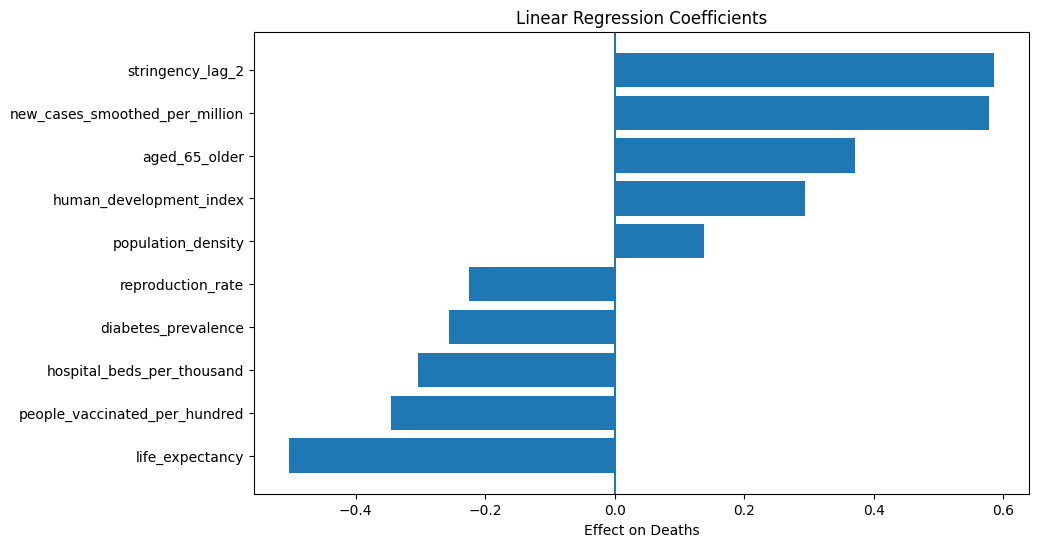

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

coef_df = pd.DataFrame({
    'Feature': [
        'stringency_lag_2',
        'new_cases_smoothed_per_million',
        'aged_65_older',
        'human_development_index',
        'population_density',
        'reproduction_rate',
        'diabetes_prevalence',
        'hospital_beds_per_thousand',
        'people_vaccinated_per_hundred',
        'life_expectancy'
    ],
    'Coefficient': [
        0.585307,
        0.577344,
        0.370707,
        0.294598,
        0.137943,
        -0.225014,
        -0.255247,
        -0.304151,
        -0.344916,
        -0.502467
    ]
})

coef_df = coef_df.sort_values(by='Coefficient')

plt.figure(figsize=(10,6))
plt.barh(coef_df['Feature'], coef_df['Coefficient'])
plt.axvline(0)
plt.title("Linear Regression Coefficients")
plt.xlabel("Effect on Deaths")
plt.show()

In [13]:
from sklearn.metrics import r2_score

y_pred = model.predict(X_scaled)

print("R²:", r2_score(y, y_pred))

R²: 0.269137655008285


Train R²: 0.9828553343253773
Test R²: 0.26339906186642326

Feature Importance:
                          Feature  Importance
0  new_cases_smoothed_per_million    0.283668
3   people_vaccinated_per_hundred    0.221908
2                stringency_lag_2    0.190261
1               reproduction_rate    0.103430
6             diabetes_prevalence    0.081285
5                   aged_65_older    0.033591
4              population_density    0.026942
9         human_development_index    0.021616
8                 life_expectancy    0.019350
7      hospital_beds_per_thousand    0.017948


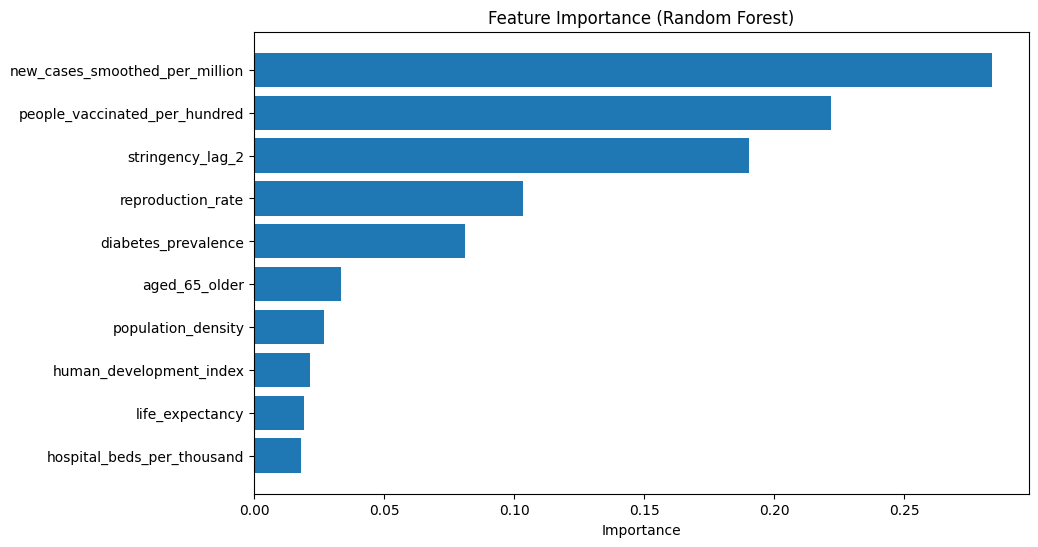

In [14]:
# ===============================
# TIME-BASED TRAIN / TEST SPLIT + RANDOM FOREST
# ===============================

import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# 1. Sort data by country and time
final_model_df = final_model_df.sort_values(["country", "week"])

# 2. Create time-based split (80% train, 20% test)
split_date = final_model_df["week"].quantile(0.8)

train_df = final_model_df[final_model_df["week"] <= split_date]
test_df  = final_model_df[final_model_df["week"] > split_date]

# 3. Define features (X) and target (y)
X_train = train_df.drop(columns=["new_deaths_smoothed_per_million", "country", "week"])
y_train = train_df["new_deaths_smoothed_per_million"]

X_test = test_df.drop(columns=["new_deaths_smoothed_per_million", "country", "week"])
y_test = test_df["new_deaths_smoothed_per_million"]

# 4. Initialize Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# 5. Train model
rf_model.fit(X_train, y_train)

# 6. Predictions
y_pred_train = rf_model.predict(X_train)
y_pred_test = rf_model.predict(X_test)

# 7. Evaluate performance
print("Train R²:", r2_score(y_train, y_pred_train))
print("Test R²:", r2_score(y_test, y_pred_test))

# 8. Feature Importance
rf_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance:")
print(rf_importance)

# 9. (Optional) Plot feature importance
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(rf_importance["Feature"], rf_importance["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.show()

In [15]:
## reproduction rate: On average, how many people one infected person spreads the virus to at a given time

### Starting over (IGNORE, didn't work out)

In [50]:
df = owid.copy()
if 'location' in df.columns:
    df = df.rename(columns={'location': 'country'})

# Convert date
df['date'] = pd.to_datetime(df['date'])

# Keep only selected countries
selected_countries = [
    "United States", "China", "New Zealand", "Sweden", "Brazil", "Germany",
    "United Kingdom", "France", "Italy", "Spain",
    "Canada", "Australia", "Japan", "South Korea", "Singapore",
    "Netherlands", "Belgium", "Denmark", "Norway"
]

df = df[df['country'].isin(selected_countries)].copy()

# Sort
df = df.sort_values(['country', 'date'])

In [51]:
df['week'] = df['date'].dt.to_period('W')

In [52]:
# =========================
# 4. Aggregate to weekly level
# =========================
# Explanatory features:
# - stringency_index: time-varying, use mean
# - people_vaccinated_per_hundred: time-varying, use mean
# - aged_65_older: static, use first
# - hospital_beds_per_thousand: static, use first
# - human_development_index: static, use first
# - population_density: static, use first
# - target: new_deaths_smoothed_per_million, use mean

weekly_df = (
    df.groupby(['country', 'week'])
    .agg({
        'stringency_index': 'mean',
        'people_vaccinated_per_hundred': 'mean',
        'aged_65_older': 'first',
        'hospital_beds_per_thousand': 'first',
        'human_development_index': 'first',
        'population_density': 'first',
        'new_deaths_smoothed_per_million': 'mean'
    })
    .reset_index()
)

In [53]:
weekly_df = weekly_df.sort_values(['country', 'week'])
weekly_df.head()
weekly_df['stringency_index'] = (
    weekly_df.groupby('country')['stringency_index'].ffill()
)

In [54]:
weekly_df['stringency_lag_2'] = (
    weekly_df.groupby('country')['stringency_index'].shift(2)
)
weekly_df.head()

,country,week,stringency_index,people_vaccinated_per_hundred,aged_65_older,hospital_beds_per_thousand,human_development_index,population_density,new_deaths_smoothed_per_million,stringency_lag_2
0,Australia,2019-12-30/2020-01-05,0.000000,NaN,15.5,3.84,0.94,3.2,NaN,NaN
1,Australia,2020-01-06/2020-01-12,0.000000,NaN,15.5,3.84,0.94,3.2,0.0,NaN
2,Australia,2020-01-13/2020-01-19,0.000000,NaN,15.5,3.84,0.94,3.2,0.0,0.0
3,Australia,2020-01-20/2020-01-26,1.588571,NaN,15.5,3.84,0.94,3.2,0.0,0.0
4,Australia,2020-01-27/2020-02-02,7.940000,NaN,15.5,3.84,0.94,3.2,0.0,0.0


In [55]:
weekly_df['people_vaccinated_per_hundred'] = (
    weekly_df.groupby('country')['people_vaccinated_per_hundred']
    .ffill()
    .fillna(0)
)

# Check missingness before dropping
missing_pct = (weekly_df.isna().mean() * 100).round(2)
print("Missing values (%):")
print(missing_pct.sort_values(ascending=False))

Missing values (%):
new_deaths_smoothed_per_million    4.16
stringency_lag_2                   0.83
week                               0.00
country                            0.00
stringency_index                   0.00
people_vaccinated_per_hundred      0.00
hospital_beds_per_thousand         0.00
aged_65_older                      0.00
population_density                 0.00
human_development_index            0.00
dtype: float64


In [56]:
features = [
    'stringency_lag_2',
    'people_vaccinated_per_hundred',
    'aged_65_older',
    'hospital_beds_per_thousand',
    'population_density'
]

target = 'new_deaths_smoothed_per_million'

In [57]:
# =========================
# 8. Create final modeling dataframe
# =========================
model_df = weekly_df.dropna(subset=features + [target]).copy()

# Convert week to timestamp for splitting / plotting
model_df['week'] = model_df['week'].dt.to_timestamp()

print("\nModel dataframe shape:", model_df.shape)
print(model_df.head())


Model dataframe shape: (4353, 10)
     country       week  stringency_index  people_vaccinated_per_hundred  \
2  Australia 2020-01-13          0.000000                            0.0   
3  Australia 2020-01-20          1.588571                            0.0   
4  Australia 2020-01-27          7.940000                            0.0   
5  Australia 2020-02-03         19.440000                            0.0   
6  Australia 2020-02-10         19.440000                            0.0   

   aged_65_older  hospital_beds_per_thousand  human_development_index  \
2           15.5                        3.84                     0.94   
3           15.5                        3.84                     0.94   
4           15.5                        3.84                     0.94   
5           15.5                        3.84                     0.94   
6           15.5                        3.84                     0.94   

   population_density  new_deaths_smoothed_per_million  stringency_la

In [58]:
corr_matrix = model_df[features + [target]].corr()
print("\nCorrelation matrix:")
print(corr_matrix)




Correlation matrix:
                                 stringency_lag_2  \
stringency_lag_2                         1.000000   
people_vaccinated_per_hundred           -0.553064   
aged_65_older                           -0.093630   
hospital_beds_per_thousand               0.019498   
population_density                      -0.011107   
new_deaths_smoothed_per_million          0.358565   

                                 people_vaccinated_per_hundred  aged_65_older  \
stringency_lag_2                                     -0.553064      -0.093630   
people_vaccinated_per_hundred                         1.000000      -0.045683   
aged_65_older                                        -0.045683       1.000000   
hospital_beds_per_thousand                           -0.018279       0.351767   
population_density                                    0.048173      -0.226003   
new_deaths_smoothed_per_million                      -0.245465       0.066742   

                                 hospit

In [47]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [59]:
# =========================
# 10. VIF check for multicollinearity
# =========================
X_vif = model_df[features].copy()

vif_df = pd.DataFrame()
vif_df['Feature'] = X_vif.columns
vif_df['VIF'] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

print("\nVIF values:")
print(vif_df.sort_values(by='VIF', ascending=False))


VIF values:
                         Feature       VIF
2                  aged_65_older  8.295818
3     hospital_beds_per_thousand  3.411834
1  people_vaccinated_per_hundred  3.273769
0               stringency_lag_2  3.005149
4             population_density  1.119610


In [60]:
# =========================
# 11. Time-based train/test split
# =========================
cutoff = model_df['week'].quantile(0.8)

train_df = model_df[model_df['week'] <= cutoff].copy()
test_df = model_df[model_df['week'] > cutoff].copy()

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Cutoff week:", cutoff)


Train shape: (3489, 5)
Test shape: (864, 5)
Cutoff week: 2023-07-17 00:00:00


In [61]:
# =========================
# 12. Run linear regression
# =========================
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

y_pred_lin = lin_model.predict(X_test)

rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred_lin))
r2_lin = r2_score(y_test, y_pred_lin)

print("\nLinear Regression Results")
print("RMSE:", rmse_lin)
print("R²:", r2_lin)



Linear Regression Results
RMSE: 0.7492816047415334
R²: -2.5341639331755412


In [62]:
# =========================
# 13. Coefficients table
# =========================
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': lin_model.coef_
}).sort_values(by='Coefficient', ascending=False)

print("\nLinear Regression Coefficients:")
print(coef_df)


Linear Regression Coefficients:
                         Feature  Coefficient
2                  aged_65_older     0.074273
0               stringency_lag_2     0.029743
4             population_density    -0.000136
1  people_vaccinated_per_hundred    -0.000834
3     hospital_beds_per_thousand    -0.120934


In [63]:
# =========================
# 14. Optional: Ridge regression if VIF is a little high
# =========================
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

y_pred_ridge = ridge_model.predict(X_test)

rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

print("\nRidge Regression Results")
print("RMSE:", rmse_ridge)
print("R²:", r2_ridge)


Ridge Regression Results
RMSE: 0.7492779532275984
R²: -2.5341294868009783


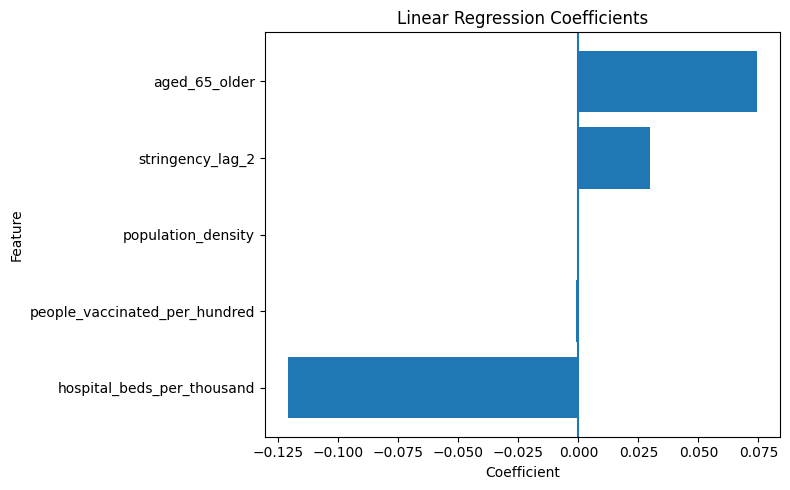

In [64]:
# =========================
# 15. Plot coefficients
# =========================
coef_plot = coef_df.sort_values('Coefficient')

plt.figure(figsize=(8, 5))
plt.barh(coef_plot['Feature'], coef_plot['Coefficient'])
plt.axvline(0)
plt.title('Linear Regression Coefficients')
plt.xlabel('Coefficient')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()
